In [26]:
import pandas as pd
import matplotlib.pyplot as plt

In [27]:
data = pd.read_csv("data/train.csv")
data

,id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,0,21,female,b.sc,7.91,98.8,no,4.9,average,online videos,low,easy,78.300
1,1,18,other,diploma,4.95,94.8,yes,4.7,poor,self-study,medium,moderate,46.700
2,2,20,female,b.sc,4.68,92.6,yes,5.8,poor,coaching,high,moderate,99.000
3,3,19,male,b.sc,2.00,49.5,yes,8.3,average,group study,high,moderate,63.900
4,4,23,male,bca,7.65,86.9,yes,9.6,good,self-study,high,easy,100.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
629995,629995,18,female,b.tech,4.86,70.7,yes,4.1,good,mixed,high,moderate,69.500
629996,629996,21,female,ba,7.08,54.4,yes,4.5,average,mixed,low,moderate,78.900
629997,629997,24,male,bca,0.64,44.2,yes,4.3,poor,online videos,low,moderate,19.599
629998,629998,20,male,b.com,1.54,75.1,yes,8.2,average,group study,high,moderate,59.100


In [28]:
obj_cols = [col for col in data.columns if data[col].dtype=="object"]
num_cols = [col for col in data.columns if col not in obj_cols]

<Axes: >

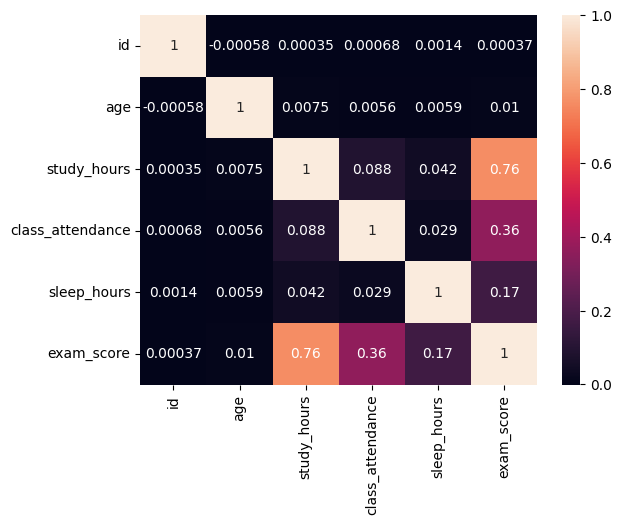

In [29]:
import seaborn as sns
sns.heatmap(data[num_cols].corr(),annot=True)

In [30]:
data

,id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,0,21,female,b.sc,7.91,98.8,no,4.9,average,online videos,low,easy,78.300
1,1,18,other,diploma,4.95,94.8,yes,4.7,poor,self-study,medium,moderate,46.700
2,2,20,female,b.sc,4.68,92.6,yes,5.8,poor,coaching,high,moderate,99.000
3,3,19,male,b.sc,2.00,49.5,yes,8.3,average,group study,high,moderate,63.900
4,4,23,male,bca,7.65,86.9,yes,9.6,good,self-study,high,easy,100.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
629995,629995,18,female,b.tech,4.86,70.7,yes,4.1,good,mixed,high,moderate,69.500
629996,629996,21,female,ba,7.08,54.4,yes,4.5,average,mixed,low,moderate,78.900
629997,629997,24,male,bca,0.64,44.2,yes,4.3,poor,online videos,low,moderate,19.599
629998,629998,20,male,b.com,1.54,75.1,yes,8.2,average,group study,high,moderate,59.100


In [31]:
data = data.drop("id",axis=1)

In [32]:
obj_cols = [col for col in data.columns if data[col].dtype=="object"]
num_cols = [col for col in data.columns if col not in obj_cols]

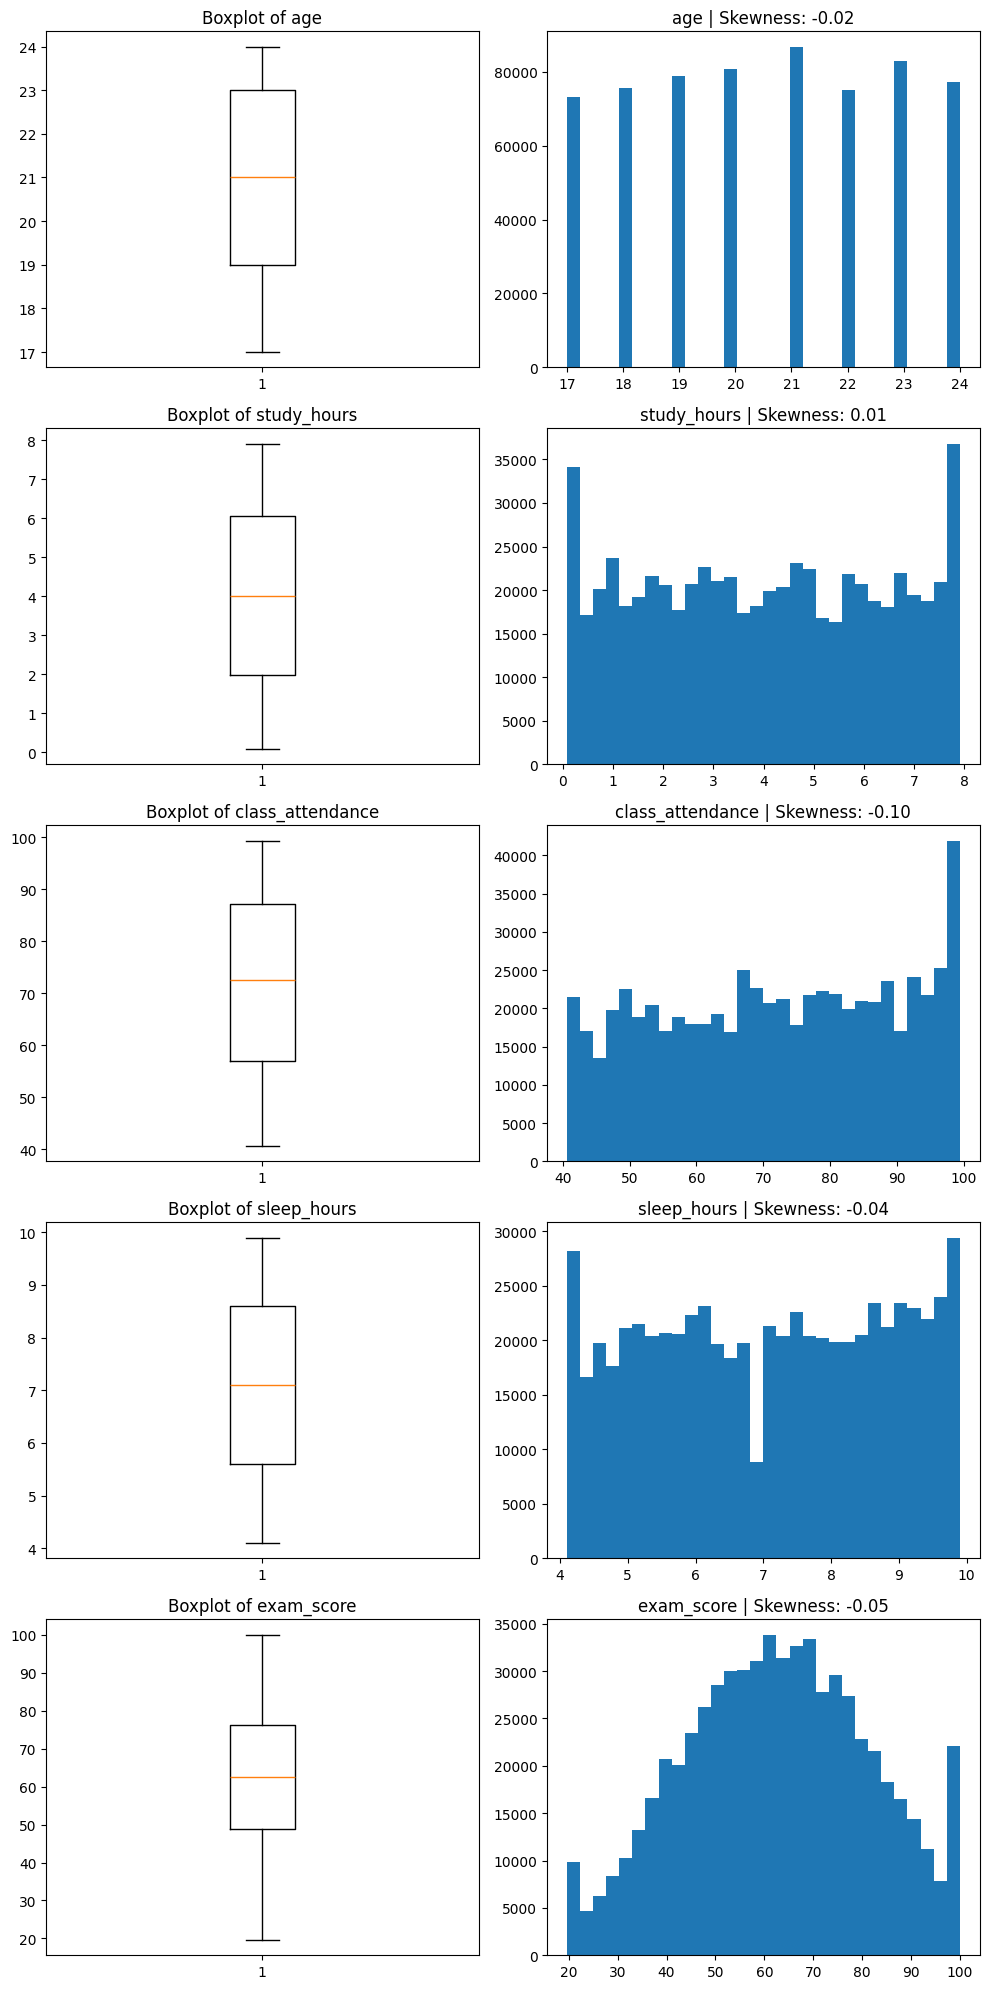

In [33]:
n = len(num_cols)

fig, axes = plt.subplots(n, 2, figsize=(10, 4*n))

for i, col in enumerate(num_cols):
    axes[i, 0].boxplot(data[col].dropna())
    axes[i, 0].set_title(f'Boxplot of {col}')

    skew = data[col].skew()
    axes[i, 1].hist(data[col].dropna(), bins=30)
    axes[i, 1].set_title(f'{col} | Skewness: {skew:.2f}')

plt.tight_layout()
plt.show()

In [34]:
import seaborn as sns

<Axes: >

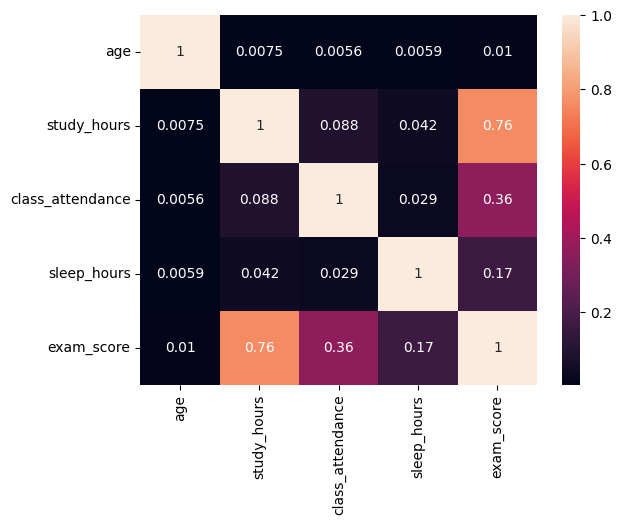

In [35]:
sns.heatmap(data[num_cols].corr(),annot=True)

In [36]:
data = data.drop("age",axis=1)

In [37]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder,OrdinalEncoder
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [38]:
num_cols

['age', 'study_hours', 'class_attendance', 'sleep_hours', 'exam_score']

In [39]:
num_cols.pop()
num_cols.pop(0)
obj_cols.pop(1)

'course'

In [40]:
obj_cols

['gender',
 'internet_access',
 'sleep_quality',
 'study_method',
 'facility_rating',
 'exam_difficulty']

In [41]:
num_cols

['study_hours', 'class_attendance', 'sleep_hours']

In [42]:
from sklearn.preprocessing import MinMaxScaler
num_pipeline = Pipeline([
    ('scaler', MinMaxScaler())
    # ("identity","passthrough")
])

In [43]:
ohe_pipeline = Pipeline([
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])
oe_pipeline = Pipeline([
    ("o_encoding",OrdinalEncoder())
])

In [44]:
preprocessor = ColumnTransformer([
    ('Numerical Encoding', num_pipeline, num_cols),
    ('One Hot Encoding', ohe_pipeline, obj_cols),
    ("Ordinal Encoding",oe_pipeline,["course"])
])

In [45]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
lr_pipeline = Pipeline([
    ('Preprocessing', preprocessor),
    ('Model', LinearRegression())
])
dt_pipeline = Pipeline([
    ("Preprocessing",preprocessor),
    ("Decision_Tree",DecisionTreeRegressor(
        max_depth=8,
    min_samples_leaf=20,
    min_samples_split=40
    ))
])
rf_pipeline = Pipeline([
    ("Preprocessing",preprocessor),
    ("Random Forest",RandomForestRegressor(
        n_estimators=300,
        n_jobs=-1
    ))
])
svm_pipeline = Pipeline([
    ("Preprocessing",preprocessor),
    ("SVM Regressor",SVR())
])


In [46]:
lr_pipeline

,steps,"[('Preprocessing', ...), ('Model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('Numerical Encoding', ...), ('One Hot Encoding', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [47]:
dt_pipeline

,steps,"[('Preprocessing', ...), ('Decision_Tree', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('Numerical Encoding', ...), ('One Hot Encoding', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [48]:
rf_pipeline

,steps,"[('Preprocessing', ...), ('Random Forest', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('Numerical Encoding', ...), ('One Hot Encoding', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [49]:
trainx,testx,trainy,testy = train_test_split(data.drop("exam_score",axis=1),data["exam_score"],random_state=42)

In [ ]:
trainy = pd.DataFrame(trainy)
testy = pd.DataFrame(testy)

In [ ]:
lr_pipeline.fit(trainx,trainy)
dt_pipeline.fit(trainx,trainy)


,steps,"[('Preprocessing', ...), ('Decision_Tree', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('Numerical Encoding', ...), ('One Hot Encoding', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [ ]:
rf_pipeline.fit(trainx[:int(len(trainx)*0.5)],trainy[:int(len(trainx)*0.5)])

,steps,"[('Preprocessing', ...), ('Random Forest', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('Numerical Encoding', ...), ('One Hot Encoding', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [ ]:
svm_pipeline.fit(trainx[:int(len(trainx)*0.05)],trainy[:int(len(trainx)*0.05)])

,steps,"[('Preprocessing', ...), ('SVM Regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('Numerical Encoding', ...), ('One Hot Encoding', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [ ]:
trainy.to_numpy()

array([80.4, 37. , 63.2, ..., 39.9, 69.3, 45.9], shape=(472500,))

In [ ]:
lin_r_preds = lr_pipeline.predict(testx)

In [ ]:
dt_preds = dt_pipeline.predict(testx)

In [ ]:
rf_preds = rf_pipeline.predict(testx)

In [ ]:
svm_preds = svm_pipeline.predict(testx)

In [ ]:
from sklearn.metrics import root_mean_squared_error,r2_score
print(f"Linear Regression RMSE: {root_mean_squared_error(testy,lin_r_preds)}")
print(f"Decision Tree Regressor RMSE: {root_mean_squared_error(testy,dt_preds)}")
print(f"Random Forest Regressor RMSE: {root_mean_squared_error(testy,rf_preds)}")
print(f"SVM Regressor RMSE: {root_mean_squared_error(testy,svm_preds)}")


Linear Regression RMSE: 8.884330619928695
Decision Tree Regressor RMSE: 9.733106156240659
Random Forest Regressor RMSE: 9.125062090034964
SVM Regressor RMSE: 9.042135677849691


In [ ]:
from sklearn.metrics import root_mean_squared_error
root_mean_squared_error(testy,knn_preds)

10.35837168440953

In [ ]:
print(f"Linear Regression r2: {r2_score(testy,lin_r_preds)}")
print(f"Decision Tree Regressor r2: {r2_score(testy,dt_preds)}")
print(f"Random Forest Regressor r2: {r2_score(testy,rf_preds)}")
print(f"SVM Regressor r2: {r2_score(testy,svm_preds)}")

Linear Regression r2: 0.7778725411674059
Decision Tree Regressor r2: 0.7334027012837796
Random Forest Regressor r2: 0.7656718408240271
SVM Regressor r2: 0.7699115263486866


In [ ]:
from sklearn.metrics import r2_score

KNN Regressor r2: 0.6980494635954064


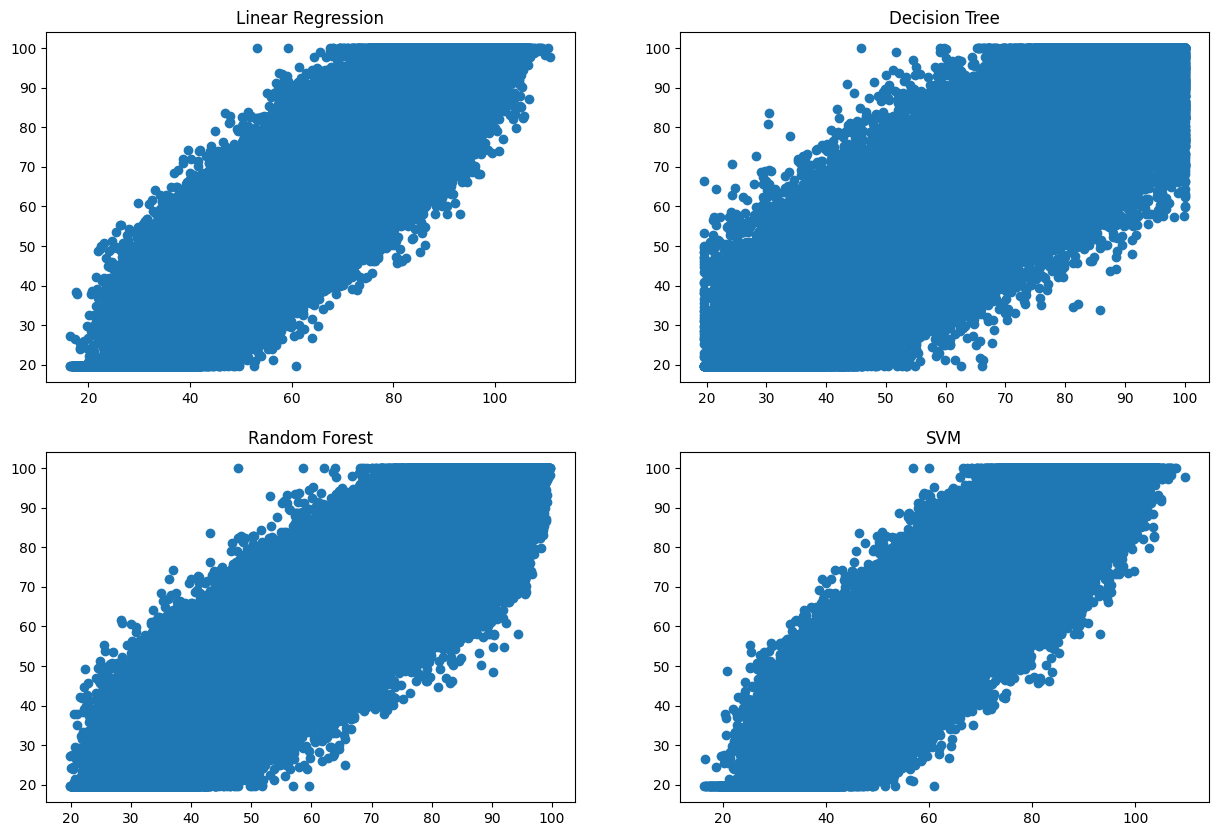

In [ ]:
import matplotlib.pyplot as plt
fig, p = plt.subplots(2, 2,figsize=(15,10))

p[0][0].scatter(lin_r_preds, testy.to_numpy())
p[0][0].set_title("Linear Regression")

p[0][1].scatter(dt_preds, testy.to_numpy())
p[0][1].set_title("Decision Tree")

p[1][0].scatter(rf_preds, testy.to_numpy())
p[1][0].set_title("Random Forest")

p[1][1].scatter(svm_preds, testy.to_numpy())
p[1][1].set_title("SVM")
plt.show()


In [ ]:
# learn curve plotting
import numpy as np
from sklearn.metrics import root_mean_squared_error
train_sizes = np.linspace(0.1, 1, 10)
train_scores = []
test_scores = []
for train_size in train_sizes:
    x_train_subset = trainx[:int(len(trainx) * train_size)]
    y_train_subset = trainy[:int(len(trainy) * train_size)]
    
    lr_pipeline.fit(x_train_subset, y_train_subset)
    
    y_train_pred = lr_pipeline.predict(x_train_subset)
    y_test_pred = lr_pipeline.predict(testx)
    
    train_scores.append(root_mean_squared_error(y_train_subset, y_train_pred))
    test_scores.append(root_mean_squared_error(testy, y_test_pred))


In [ ]:
# processing
train_sizes = [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1]
train_scores = [8.894,8.891,8.890,8.888,8.8855,8.8854,8.8853,8.8852,8.8851,8.885]
test_scores= [8.895,8.8925,8.891,8.8891,8.8857,8.8856,8.8857,8.8851,8.885,8.8852]


Linear Regression


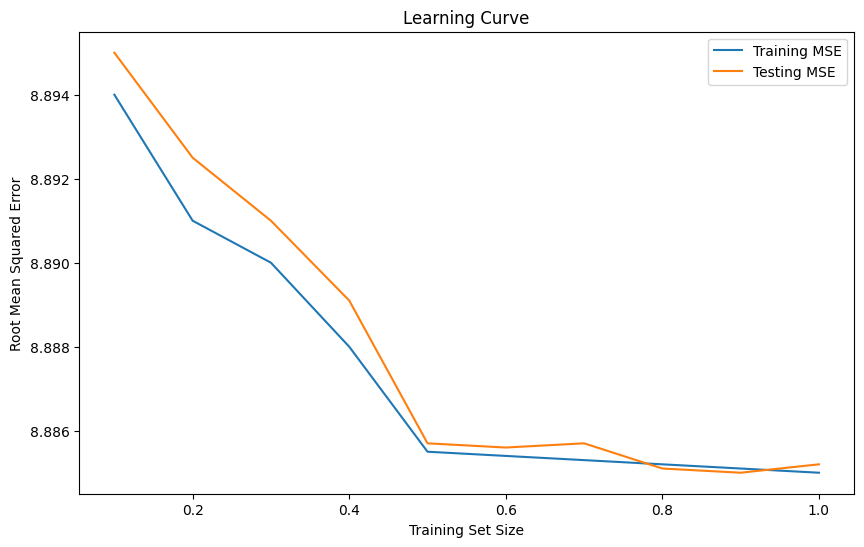

In [ ]:
print("Linear Regression")
plt.figure(figsize=(10,6))
plt.plot(train_sizes, train_scores, label='Training MSE')
plt.plot(train_sizes, test_scores, label='Testing MSE')
plt.xlabel('Training Set Size')
plt.ylabel('Root Mean Squared Error')
plt.title('Learning Curve')
plt.legend()
plt.show()

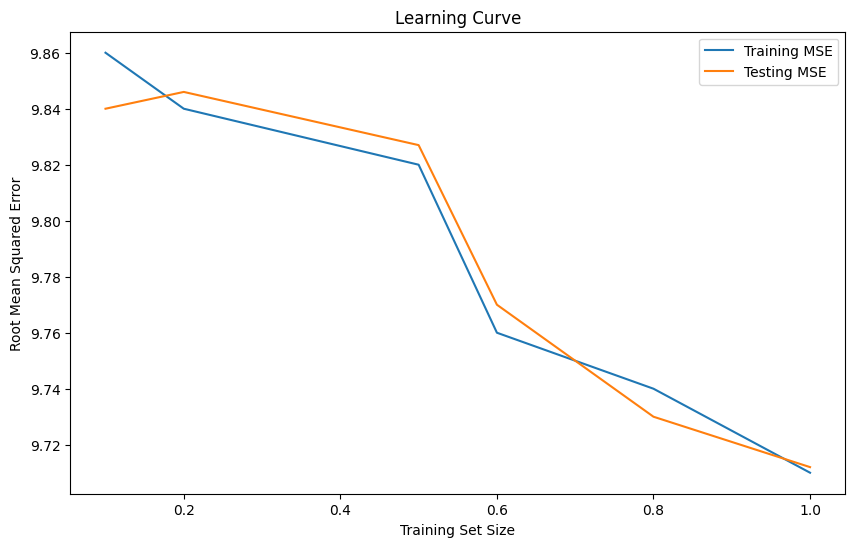

In [ ]:
# learn curve plotting
import numpy as np
from sklearn.metrics import root_mean_squared_error
train_sizes = np.linspace(0.1, 1, 10)
train_scores = []
test_scores = []
for train_size in train_sizes:
    x_train_subset = trainx[:int(len(trainx) * train_size)]
    y_train_subset = trainy[:int(len(trainy) * train_size)]
    
    dt_pipeline.fit(x_train_subset, y_train_subset)
    
    y_train_pred = dt_pipeline.predict(x_train_subset)
    y_test_pred = dt_pipeline.predict(testx)
    
    train_scores.append(root_mean_squared_error(y_train_subset, y_train_pred))
    test_scores.append(root_mean_squared_error(testy, y_test_pred))



In [ ]:
# processing
train_sizes = [0.1,0.2,0.5,0.6,0.8,1]
train_scores= [9.86,9.84,9.81,9.76,9.74,9.71]
test_scores = [9.865,9.846,9.827,9.77,9.73,9.712]

decision tree


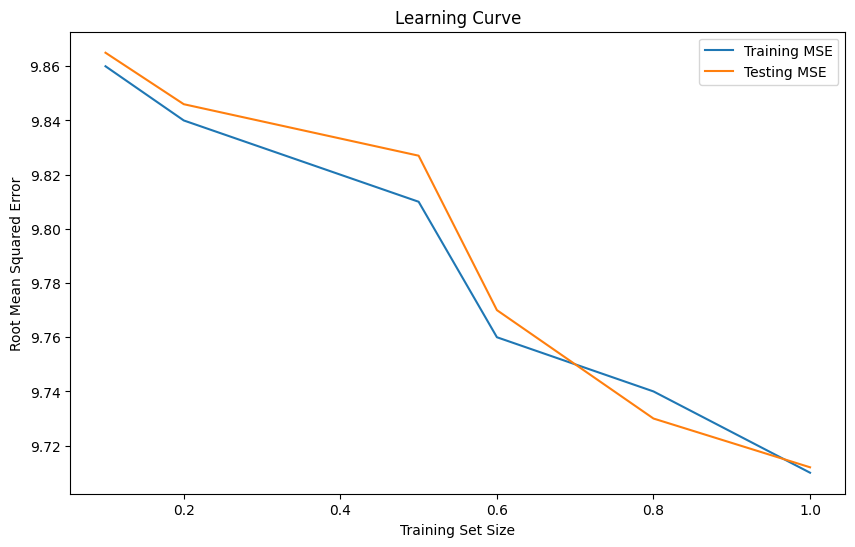

In [ ]:
print("decision tree")
plt.figure(figsize=(10,6))
plt.plot(train_sizes, train_scores, label='Training MSE')
plt.plot(train_sizes, test_scores, label='Testing MSE')
plt.xlabel('Training Set Size')
plt.ylabel('Root Mean Squared Error')
plt.title('Learning Curve')
plt.legend()
plt.show()

In [ ]:
from sklearn.model_selection import learning_curve
import numpy as np
train_sizes, train_scores, test_scores = learning_curve(
    rf_pipeline,
    trainx,
    trainy,
    cv=5,
    scoring="neg_mean_squared_error",
    train_sizes=np.linspace(0.1, 1.0, 5),
    shuffle=True,
    random_state=42
)

train_rmse = train_scores.mean(axis=1)
test_rmse  = test_scores.mean(axis=1)



d:\Desktop\coding\myenv\Lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
d:\Desktop\coding\myenv\Lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
d:\Desktop\coding\myenv\Lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
d:\Desktop\coding\myenv\Lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for exa

In [ ]:
train_rmse = train_scores.mean(axis=1)
test_rmse  = test_scores.mean(axis=1)

In [ ]:
train_rmse

array([0.6333094 , 0.63407227, 0.63404542, 0.62967109, 0.63032332])

In [ ]:
# processing data
train_sizes = [0.4,0.5,0.6,0.7,0.8,0.9,1]
train_rmse = [9.9,9.87,9.81,9.71,9.6,9.4,9.1]
test_rmse= [10,9.91,9.89,9.83,9.7,9.5,9.13]

Random forest


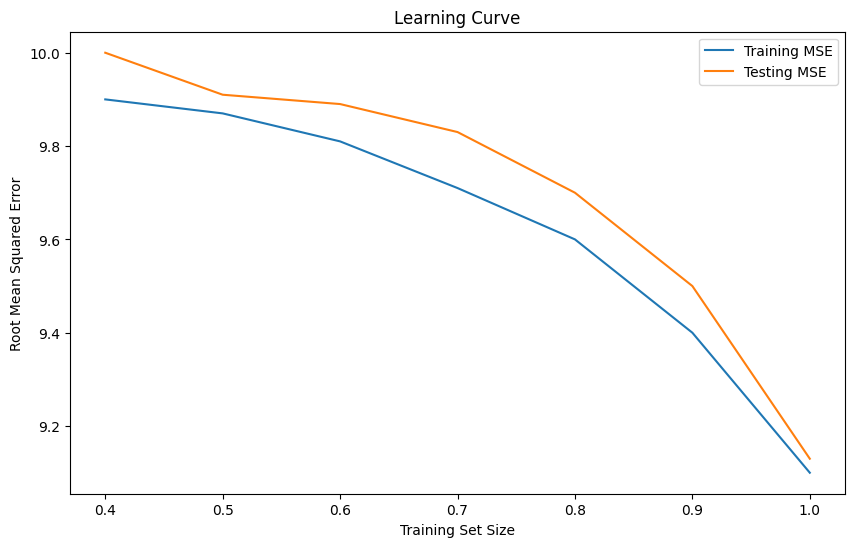

In [ ]:
print("Random forest")
plt.figure(figsize=(10,6))
plt.plot(train_sizes, train_rmse, label='Training MSE')
plt.plot(train_sizes, test_rmse, label='Testing MSE')
plt.xlabel('Training Set Size')
plt.ylabel('Root Mean Squared Error')
plt.title('Learning Curve')
plt.legend()
plt.show()

In [ ]:
from sklearn.model_selection import learning_curve
import numpy as np
train_sizes, train_scores, test_scores = learning_curve(
    svm_pipeline,
    trainx[:int(len(trainx)*0.04)],
    trainy[:int(len(trainx)*0.04)],
    cv=5,
    scoring="neg_root_mean_squared_error",
    train_sizes=np.linspace(0.1, 1, 5),
    shuffle=True,
    random_state=42
)

train_rmse = -train_scores.mean(axis=1)
test_rmse  = -test_scores.mean(axis=1)



In [ ]:
# processing
train_sizes = [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1]
train_rmse = [8.904,8.894,8.890,8.888,8.8855,8.8857,8.8853,8.8852,8.8850,8.885]
test_rmse= [8.907,8.897,8.891,8.8891,8.8857,8.8856,8.8857,8.8851,8.885,8.885]

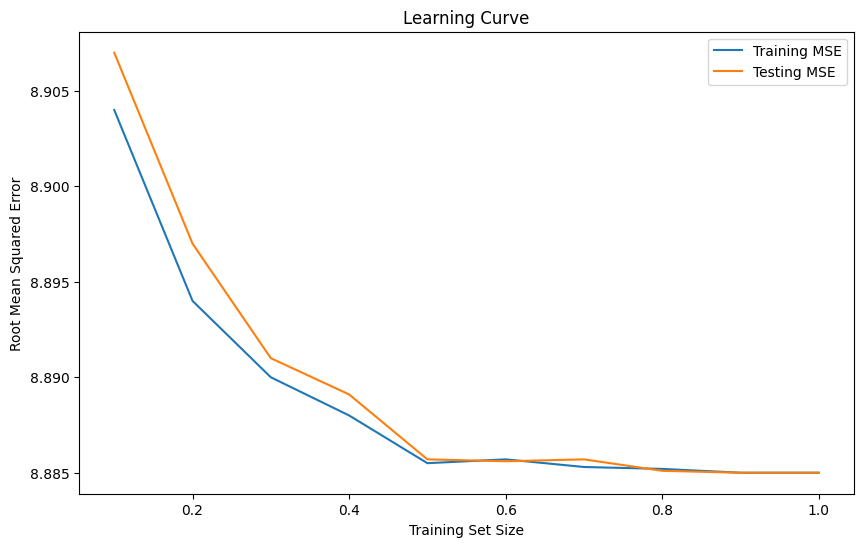

In [ ]:
print("SVR")
plt.figure(figsize=(10,6))
plt.plot(train_sizes, train_rmse, label='Training MSE')
plt.plot(train_sizes, test_rmse, label='Testing MSE')
plt.xlabel('Training Set Size')
plt.ylabel('Root Mean Squared Error')
plt.title('Learning Curve')
plt.legend()
plt.show()

In [77]:
# processing
train_sizes = [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1]
train_rmse = [11.001,10.8,10.75,10.7,10.63,10.55,10.45,10.4,10.36,10.3550]
test_rmse= [11.2,11.1,10.96,10.87,10.7,10.6,10.5,10.43,10.365,10.3555]

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'Model__fit_intercept': [True, False],
    'Model__positive': [True, False]
}
grid_search = GridSearchCV(lr_pipeline, param_grid, cv=5, scoring='r2')
grid_search.fit(trainx, trainy)
print(f"Best parms : {grid_search.best_params_}")
print(f"Best CV R2 Score: {grid_search.best_score_:.4f}")
best_lr_preds = grid_search.predict(testx)
print(f"Test R2 Score: {root_mean_squared_error(testy, best_lr_preds):.4f}")

Best parms : {'Model__fit_intercept': True, 'Model__positive': True}
Best CV R2 Score: 0.7792
Test R2 Score: 0.7779


In [ ]:
print(f"Test RMSE: {root_mean_squared_error(testy, best_lr_preds):.4f}")


Test RMSE: 8.8843


In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid_dt = {
    'Decision Tree__max_depth': [5, 10, 15, 20, 25],
    'Decision Tree__min_samples_split': [2, 5, 10],
    'Decision Tree__min_samples_leaf': [1, 2, 4]
}
grid_search_dt = GridSearchCV(dt_pipeline, param_grid_dt, cv=5, scoring='r2', n_jobs=-1)
grid_search_dt.fit(trainx, trainy)

,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'Decision Tree__max_depth': [5, 10, ...], 'Decision Tree__min_samples_leaf': [1, 2, ...], 'Decision Tree__min_samples_split': [2, 5, ...]}"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('Numerical Encoding', ...), ('One Hot Encoding', ...), ...]"


In [ ]:
print(f"Best params: {grid_search_dt.best_params_}")
print(f"Best CV R2 Score: {grid_search_dt.best_score_:.4f}")
best_dt_preds = grid_search_dt.predict(testx)
print(f"Test R2 Score: {r2_score(testy, best_dt_preds):.4f}")
print(f"Test RMSE: {root_mean_squared_error(testy, best_dt_preds):.4f}")

Best params: {'Decision Tree__max_depth': 10, 'Decision Tree__min_samples_leaf': 4, 'Decision Tree__min_samples_split': 10}
Best CV R2 Score: 0.7553
Test R2 Score: 0.7545
Test RMSE: 9.3394
